### **1 Perceptron**


#### 1.1 What is a Perceptron?

A perceptron is a simple linear classifier.

Given an input vector:

$$
x = (x_1, x_2, \dots, x_d)
$$

a weight vector:

$$
w = (w_1, w_2, \dots, w_d)
$$

and a bias term:

$$
b
$$

the perceptron computes a score:

$$
z = w^\top x + b
$$

where:

$$
w^\top x = w_1x_1 + w_2x_2 + \cdots + w_dx_d
$$

The prediction is made by checking the sign of the score:

$$
\hat{y} = \text{sign}(w^\top x + b)
$$

Usually, labels are represented as:

$$
y \in \{-1, +1\}
$$

So:

* If $w^\top x + b > 0$, predict $+1$
* If $w^\top x + b \le 0$, predict $-1$

---

#### 1.2 Decision Boundary

The perceptron creates a linear decision boundary:

$$
w^\top x + b = 0
$$

In 2D, this is a line.

In higher dimensions, this is a hyperplane.

The weight vector $w$ controls the orientation of the boundary.

The bias $b$ shifts the boundary.

---

#### 1.3 Correct Classification Condition

For a training example $(x_i, y_i)$, the perceptron classifies it correctly if:

$$
y_i(w^\top x_i + b) > 0
$$

Why?

If $y_i = +1$, then we want:

$$
w^\top x_i + b > 0
$$

If $y_i = -1$, then we want:

$$
w^\top x_i + b < 0
$$

Both cases can be written compactly as:

$$
y_i(w^\top x_i + b) > 0
$$

If:

$$
y_i(w^\top x_i + b) \le 0
$$

then the example is misclassified or lies exactly on the boundary.

---

#### 1.4 Perceptron Training Algorithm

Initialize:

$$
w = 0,\quad b = 0
$$

Repeat over the training data.

For each example $(x_i, y_i)$:

If:

$$
y_i(w^\top x_i + b) \le 0
$$

then update:

$$
w \leftarrow w + y_i x_i
$$

$$
b \leftarrow b + y_i
$$

Otherwise, do nothing.

---

#### 1.5 Intuition Behind the Update Rule

If a positive example is misclassified, then the score is too small.

So we move $w$ in the direction of $x_i$:

$$
w \leftarrow w + x_i
$$

If a negative example is misclassified, then the score is too large.

So we move $w$ in the opposite direction:

$$
w \leftarrow w - x_i
$$

The compact update rule is:

$$
w \leftarrow w + y_i x_i
$$

$$
b \leftarrow b + y_i
$$

---

#### 1.6 Perceptron Loss

A common perceptron loss is:

$$
\ell(y,x,w,b)=\max(0,-y(w^\top x+b))
$$

If the example is correctly classified:

$$
y(w^\top x+b) > 0
$$

then:

$$
-y(w^\top x+b) < 0
$$

so the loss is:

$$
0
$$

If the example is misclassified:

$$
y(w^\top x+b) \le 0
$$

then the loss is positive.

This means the model needs to update its parameters.

---

#### 1.7 Relationship to Gradient Descent

The perceptron algorithm can be viewed as stochastic gradient descent with batch size 1.

For one training example, the loss is:

$$
\ell(y,x,w,b)=\max(0,-y(w^\top x+b))
$$

When the example is misclassified, the update is:

$$
w \leftarrow w + yx
$$

$$
b \leftarrow b + y
$$

When the example is correctly classified, there is no update.

---

#### 1.8 Convergence Theorem

If the training data is linearly separable, the perceptron algorithm is guaranteed to converge after a finite number of mistakes.

Assume:

1. All data points are bounded:

$$
\|x\| \le r
$$

2. There exists a separating hyperplane with margin $\rho$:

$$
y(x^\top w + b) \ge \rho
$$

for some normalized parameters satisfying:

$$
\|w\|^2 + b^2 \le 1
$$

Then the perceptron makes at most approximately:

$$
\frac{r^2+1}{\rho^2}
$$

mistakes before convergence.

Main idea:

* Larger margin $\rho$ means easier classification.
* Larger data radius $r$ may make classification harder.
* If data is linearly separable, perceptron eventually finds a separator.

---

#### 1.9 Limitation: XOR Problem

The perceptron can only learn linear decision boundaries.

The XOR function is not linearly separable.

Example XOR table:

| $x_1$ | $x_2$ | XOR |
|------|------|-----|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The positive and negative examples are arranged diagonally.

No single straight line can separate the two classes.

Therefore, a single-layer perceptron cannot represent XOR.

To solve XOR, we need a multilayer neural network with nonlinear activation functions.

---

#### **Summary: Perceptron**

* A perceptron is a linear classifier.
* It predicts using:

$$
\hat{y} = \text{sign}(w^\top x + b)
$$

* The decision boundary is:

$$
w^\top x + b = 0
$$

* The update rule is:

$$
w \leftarrow w + y_i x_i
$$

$$
b \leftarrow b + y_i
$$

* It converges if the data is linearly separable.
* It cannot solve non-linearly separable problems such as XOR.

### **2 Single Hidden Layer Neural Network for Binary Classification**

#### 2.1 Model Structure

A single-hidden-layer neural network contains three main parts:

1. Input layer
2. Hidden layer
3. Output layer

The input vector is:

$$
\mathbf{x} \in \mathbb{R}^n
$$

where \(n\) is the number of input features.

---

#### 2.2 Hidden Layer

The hidden layer has \(m\) hidden units.

The weight matrix and bias vector are:

$$
\mathbf{W}_1 \in \mathbb{R}^{m \times n}
$$

$$
\mathbf{b}_1 \in \mathbb{R}^m
$$

The hidden layer output is computed as:

$$
\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)
$$

where:

* \(\mathbf{h} \in \mathbb{R}^m\)
* \(\sigma\) is an element-wise activation function
* \(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1\) is the linear transformation
* \(\sigma(\cdot)\) introduces non-linearity

Without an activation function, the neural network would only represent a linear model, even if it had multiple layers.

---

#### 2.3 Output Layer

For binary classification, the output layer usually produces one scalar value.

The output weight vector and bias are:

$$
\mathbf{w}_2 \in \mathbb{R}^m
$$

$$
b_2 \in \mathbb{R}
$$

The output is:

$$
o = \mathbf{w}_2^T \mathbf{h} + b_2
$$

where \(o \in \mathbb{R}\).

For binary classification, the scalar output can be passed through a sigmoid function to obtain a probability:

$$
\hat{y} = \frac{1}{1 + e^{-o}}
$$

Then a decision can be made using a threshold, for example:

$$
\hat{y} > 0.5
$$

means class 1, otherwise class 0.

---

#### 2.4 Activation Functions

Activation functions introduce non-linearity into neural networks. They allow neural networks to learn complex patterns.

---

##### 2.4.1 Step Function

The step function is defined as:

$$
f(x) =
\begin{cases}
1, & x > 0 \\
0, & \text{otherwise}
\end{cases}
$$

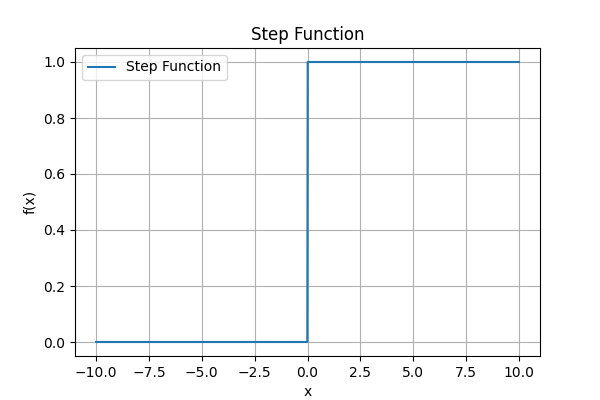

###### Properties

* Output range: \(\{0, 1\}\)
* Represents a hard decision
* Not differentiable at \(x = 0\)
* Not commonly used in modern neural networks because gradient-based optimization requires differentiable functions

---

##### 2.4.2 Sigmoid Function

The sigmoid function is defined as:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

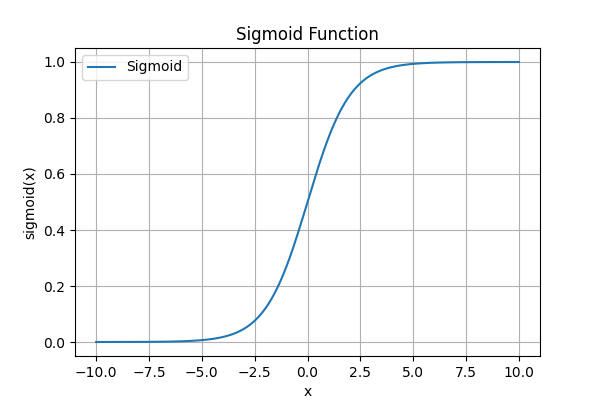

###### Properties

* Output range: \((0, 1)\)
* Smooth and differentiable
* Often used to model probabilities
* Commonly used in the output layer for binary classification

###### Derivative

$$
\sigma'(x) = \sigma(x)(1 - \sigma(x))
$$

###### Limitations

Sigmoid may suffer from the vanishing gradient problem when \(x\) is very large or very small.

---

##### 2.4.3 Tanh Function

The hyperbolic tangent function is defined as:

$$
\tanh(x) = \frac{1 - e^{-2x}}{1 + e^{-2x}}
$$

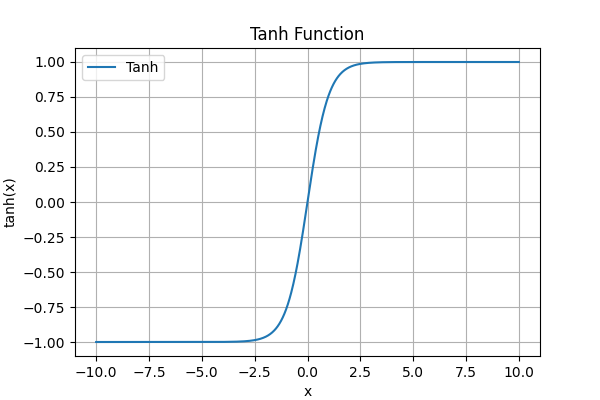

###### Properties

* Output range: \((-1, 1)\)
* Smooth and differentiable
* Zero-centered output
* Often performs better than sigmoid in hidden layers

###### Derivative

$$
\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)
$$

###### Limitation

Like sigmoid, tanh can also suffer from the vanishing gradient problem for very large or very small inputs.

---

##### 2.4.4 ReLU Function

ReLU stands for Rectified Linear Unit.

It is defined as:

$$
\text{ReLU}(x) = \max(x, 0)
$$

Equivalently:

$$
\text{ReLU}(x) =
\begin{cases}
x, & x > 0 \\
0, & x \leq 0
\end{cases}
$$

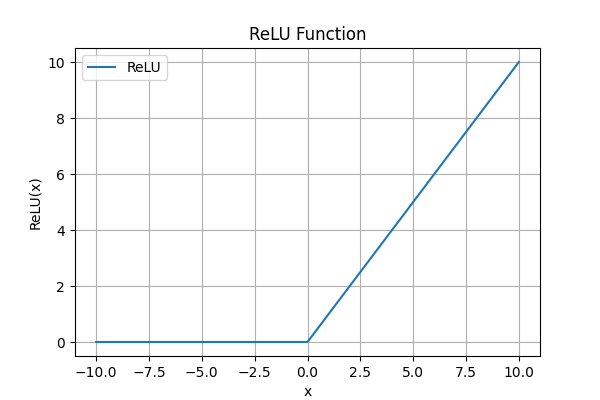

###### Properties

* Output range: \([0, \infty)\)
* Simple and computationally efficient
* Helps reduce the vanishing gradient problem
* Widely used in hidden layers of deep neural networks

###### Derivative

$$
\text{ReLU}'(x) =
\begin{cases}
1, & x > 0 \\
0, & x \leq 0
\end{cases}
$$

###### Limitation

ReLU may suffer from the dying ReLU problem, where some neurons always output zero and stop learning.

---

#### 2.5 Summary Table

| Function | Formula | Output Range | Common Use |
|---|---|---|---|
| Step | \(f(x)=1\) if \(x>0\), otherwise \(0\) | \(\{0,1\}\) | Hard classification |
| Sigmoid | \(\frac{1}{1+e^{-x}}\) | \((0,1)\) | Binary classification output |
| Tanh | \(\frac{1-e^{-2x}}{1+e^{-2x}}\) | \((-1,1)\) | Hidden layers |
| ReLU | \(\max(x,0)\) | \([0,\infty)\) | Hidden layers |

---

#### 2.6 Key Ideas

A single-hidden-layer neural network computes:

$$
\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)
$$

$$
o = \mathbf{w}_2^T \mathbf{h} + b_2
$$

The activation function is crucial because it allows the model to learn non-linear relationships.

For binary classification:

* Hidden layers often use ReLU or tanh.
* The output layer often uses sigmoid.
* The sigmoid output can be interpreted as a probability.

### **3 Multi-Class Classification and Deep Neural Networks**

#### 3.1 Multi-Class Classification

In multi-class classification, the model predicts one class from \(k\) possible classes.

The output is usually a vector:

$$
\mathbf{y} = [y_1, y_2, \dots, y_k]
$$

where each \(y_i\) represents the probability of class \(i\).

---

#### 3.2 Softmax Function

The model first produces raw scores, called logits:

$$
\mathbf{o} = [o_1, o_2, \dots, o_k]
$$

Then softmax converts logits into probabilities:

$$
\mathbf{y} = \text{softmax}(\mathbf{o})
$$

For each class:

$$
y_i = \frac{e^{o_i}}{\sum_{j=1}^{k} e^{o_j}}
$$

Softmax outputs satisfy:

$$
0 < y_i < 1
$$

$$
\sum_{i=1}^{k} y_i = 1
$$

The predicted class is:

$$
\hat{c} = \arg\max_i y_i
$$

---

#### 3.3 One-Hidden-Layer Network for Multi-Class Classification

Input:

$$
\mathbf{x} \in \mathbb{R}^n
$$

Hidden layer:

$$
\mathbf{W}_1 \in \mathbb{R}^{m \times n}, \quad \mathbf{b}_1 \in \mathbb{R}^m
$$

$$
\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)
$$

where \(\mathbf{h} \in \mathbb{R}^m\).

Output layer:

$$
\mathbf{W}_2 \in \mathbb{R}^{m \times k}, \quad \mathbf{b}_2 \in \mathbb{R}^k
$$

$$
\mathbf{o} = \mathbf{W}_2^T \mathbf{h} + \mathbf{b}_2
$$

where \(\mathbf{o} \in \mathbb{R}^k\).

Final prediction:

$$
\mathbf{y} = \text{softmax}(\mathbf{o})
$$

---

#### 3.4 Multi-Layer Neural Network

A neural network can have multiple hidden layers:

$$
\mathbf{h}_1 = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1)
$$

$$
\mathbf{h}_2 = \sigma(\mathbf{W}_2 \mathbf{h}_1 + \mathbf{b}_2)
$$

$$
\mathbf{h}_3 = \sigma(\mathbf{W}_3 \mathbf{h}_2 + \mathbf{b}_3)
$$

Output layer:

$$
\mathbf{o} = \mathbf{W}_4 \mathbf{h}_3 + \mathbf{b}_4
$$

For multi-class classification:

$$
\mathbf{y} = \text{softmax}(\mathbf{o})
$$

---

#### 3.5 Hyperparameters

Hyperparameters are settings chosen before training.

Common hyperparameters include:

* Number of hidden layers
* Number of hidden units in each layer
* Activation function
* Learning rate
* Batch size
* Number of epochs

Parameters are learned during training, such as:

$$
\mathbf{W}_1, \mathbf{W}_2, \dots
$$

$$
\mathbf{b}_1, \mathbf{b}_2, \dots
$$

---

#### 3.6 Summary

For multi-class classification:

$$
\mathbf{o} = [o_1, o_2, \dots, o_k]
$$

$$
\mathbf{y} = \text{softmax}(\mathbf{o})
$$

A deep neural network stacks multiple hidden layers to learn more complex representations.

The number of hidden layers and the size of each hidden layer are important hyperparameters.

### **4 Implementation of Multi-layered Perceptron From Scratch**

In [9]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size=256
train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)

In [10]:
# Implement a multilayer perceptron with one hidden layer of 256 hidden units
num_inputs, num_outputs, num_hiddens = 784, 10, 256

w1 = nn.Parameter(
    torch.randn(num_inputs,num_hiddens,requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens,requires_grad=True))
w2 = nn.Parameter(
    torch.randn(num_hiddens,num_outputs,requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs,requires_grad=True))
params = [w1, b1, w2, b2]

In [11]:
# Implement the ReLU activation function
def relu(x):
    a=torch.zeros_like(x)
    return torch.max(x,a)

In [12]:
# Implement the model
def net(x):
    x=x.reshape((-1,num_inputs))
    h=relu(x@w1+b1)
    return (h@w2+b2)

loss=nn.CrossEntropyLoss(reduction='none')

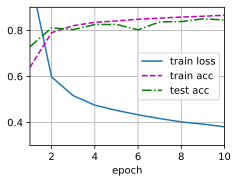

In [13]:
# Train the multilayer perceptron, using the same training process as softmax regression
num_epochs, lr = 10, 0.1
updater = torch.optim.SGD(params, lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, updater)

### **5 Simplified Implementation of Multi-layered Perceptron**

#### Code Explanation for Section 5

This section implements the same multilayer perceptron using PyTorch's high-level neural network API.

The network is defined as:

```python
net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)
```

`nn.Sequential` applies the layers in order. `nn.Flatten()` converts each image into a vector. `nn.Linear(784, 256)` is the input-to-hidden fully connected layer. `nn.ReLU()` is the nonlinear activation. `nn.Linear(256, 10)` maps the hidden representation to 10 output logits.

The weight initialization is:

```python
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)
```

`net.apply(init_weights)` visits every layer in the network. If the layer is an `nn.Linear` layer, its weights are initialized from a normal distribution with standard deviation `0.01`. A nonzero standard deviation is important because initializing all hidden-layer weights to the same value can make hidden units learn identical features.

Training uses:

```python
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
```

In the concise implementation, `net` is an `nn.Module`, so `net.parameters()` automatically collects all trainable parameters from the layers inside `nn.Sequential`. The optimizer should therefore be `trainer`, not the `updater` used in the from-scratch implementation.

#### Correspondence Between the Two Implementations

| From scratch | High-level API | Purpose |
| --- | --- | --- |
| `X.reshape((-1, 784))` | `nn.Flatten()` | Flatten each image |
| `W1`, `b1` | `nn.Linear(784, 256)` | Input-to-hidden layer |
| `relu(...)` | `nn.ReLU()` | Nonlinear activation |
| `W2`, `b2` | `nn.Linear(256, 10)` | Hidden-to-output layer |
| `params = [...]` | `net.parameters()` | Parameters passed to the optimizer |

The from-scratch version is useful for understanding what a multilayer perceptron computes internally. The concise version is closer to how neural networks are usually written in PyTorch projects because parameter management and forward propagation are handled by `nn.Module` layers.



In [14]:
# Implement the multilayer perceptron more concisely with the high-level API
import torch
from torch import nn
from d2l import torch as d2l

In [15]:
# The hidden layer contains 256 hidden units and uses the ReLU activation function
net=nn.Sequential(nn.Flatten(),nn.Linear(784,256),
                  nn.ReLU(),nn.Linear(256,10))

def init_weights(m):
    if type(m)==nn.Linear:
        nn.init.normal_(m.weight,std=0.01)

net.apply(init_weights);

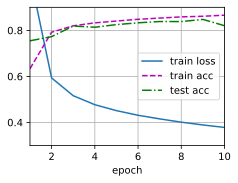

In [16]:
# Training process
batch_size,lr,num_epochs=256,0.1,10
loss=nn.CrossEntropyLoss(reduction='none')
trainer=torch.optim.SGD(net.parameters(),lr=lr)

train_iter,test_iter=d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)